# 04 — Ensemble Fusion & SAR Workflow

Combine models, find optimal threshold, generate regulatory alerts.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score
from src.data.generator import generate_transactions, get_train_test_split
from src.data.preprocessor import preprocess
from src.models.isolation_forest import train_isolation_forest, anomaly_scores_if
from src.models.ensemble import train_xgboost, ensemble_scores, find_best_threshold
from src.evaluation.metrics import evaluate, plot_pr_curves
from src.sar.workflow import generate_alerts, generate_sar_records, sar_summary
plt.rcParams['figure.dpi'] = 120

df = generate_transactions(n=20_000, fraud_rate=0.02, seed=42)
X_train, X_test, y_train, y_test = get_train_test_split(df, seed=42)
X_train_s, X_test_s, pipe = preprocess(X_train, X_test)
y_true = y_test.values
print(f"Test set: {len(y_true):,} transactions | Fraud: {y_true.mean():.2%}")

Test set: 4,000 transactions | Fraud: 2.00%


Training models...


Optimal threshold (max-F1): 0.76


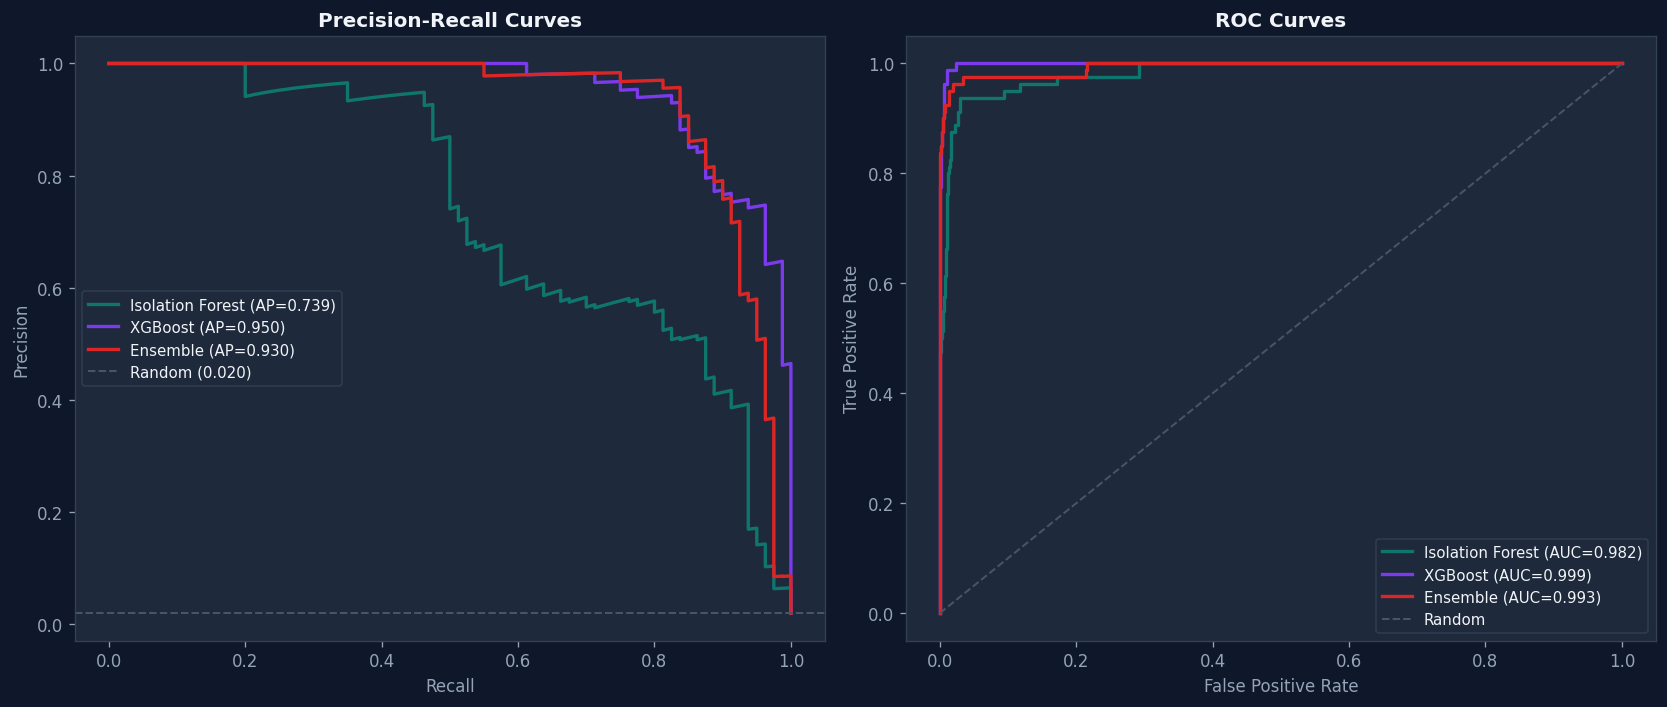

In [2]:
print("Training models...")
if_model  = train_isolation_forest(X_train_s, contamination=0.02)
xgb_model = train_xgboost(X_train_s, y_train.values)

if_scores  = anomaly_scores_if(if_model, X_test_s)
xgb_scores = xgb_model.predict_proba(X_test_s)[:, 1]
ens_scores = ensemble_scores(xgb_scores, if_scores, alpha=0.6)

best_thresh = find_best_threshold(ens_scores, y_true)
print(f"Optimal threshold (max-F1): {best_thresh:.2f}")

score_dict = {'Isolation Forest': if_scores, 'XGBoost': xgb_scores, 'Ensemble': ens_scores}
plot_pr_curves([], y_true, score_dict, save_path='../outputs/figures/04_ensemble_curves.png')

In [3]:
print("=== Final Model Comparison ===")
print(f"{'Model':22s}  AUC-PR  AUC-ROC  F1@thresh  Precision  Recall")
print("-" * 72)
for name, scores in score_dict.items():
    t = best_thresh if name=='Ensemble' else 0.50
    m = evaluate(y_true, scores, threshold=t, model_name=name)
    ap = average_precision_score(y_true, scores)
    auc = roc_auc_score(y_true, scores)
    print(f"  {name:20s}  {ap:.3f}   {auc:.3f}    {m['f1']:.3f}      {m['precision']:.3f}    {m['recall']:.3f}")

=== Final Model Comparison ===
Model                   AUC-PR  AUC-ROC  F1@thresh  Precision  Recall
------------------------------------------------------------------------
  Isolation Forest      0.739   0.982    0.642      0.507    0.875
  XGBoost               0.950   0.999    0.859      0.843    0.875
  Ensemble              0.930   0.993    0.887      0.944    0.838


## SAR Triage Workflow

In [4]:
test_df = df.loc[X_test.index].reset_index(drop=True)
alerts = generate_alerts(test_df, ens_scores, threshold=0.30)
summary = sar_summary(alerts)

print("=== SAR Alert Summary ===")
print(f"  Total alerts generated : {summary['total_alerts']:,}")
print(f"  HIGH priority (24h)    : {summary['high_priority']:,}")
print(f"  MEDIUM priority (5-day): {summary['medium_priority']:,}")
print(f"  LOW priority (monitor) : {summary['low_priority']:,}")
print(f"  SAR submission required: {summary['sar_required']:,}")
print()

sar_records = generate_sar_records(alerts, test_df)
print(f"SAR records created: {len(sar_records)}")
if sar_records:
    r = sar_records[0]
    print(f"\nSample SAR record:")
    print(f"  SAR ID    : {r.sar_id}")
    print(f"  Priority  : {r.priority}")
    print(f"  Score     : {r.anomaly_score:.4f}")
    print(f"  Deadline  : {r.filing_deadline}")
    print(f"  Narrative : {r.narrative[:150]}...")

=== SAR Alert Summary ===
  Total alerts generated : 99
  HIGH priority (24h)    : 65
  MEDIUM priority (5-day): 15
  LOW priority (monitor) : 19
  SAR submission required: 80

SAR records created: 80

Sample SAR record:
  SAR ID    : SAR-FB0B48A8
  Priority  : HIGH
  Score     : 0.8007
  Deadline  : 2026-07-23T10:54:29.974168+00:00
  Narrative : Transaction TXN0019448 generated a HIGH priority alert with anomaly score 0.8007. Reasons: Round-amount transaction ≥ £5,000 (ML indicator). This SAR ...


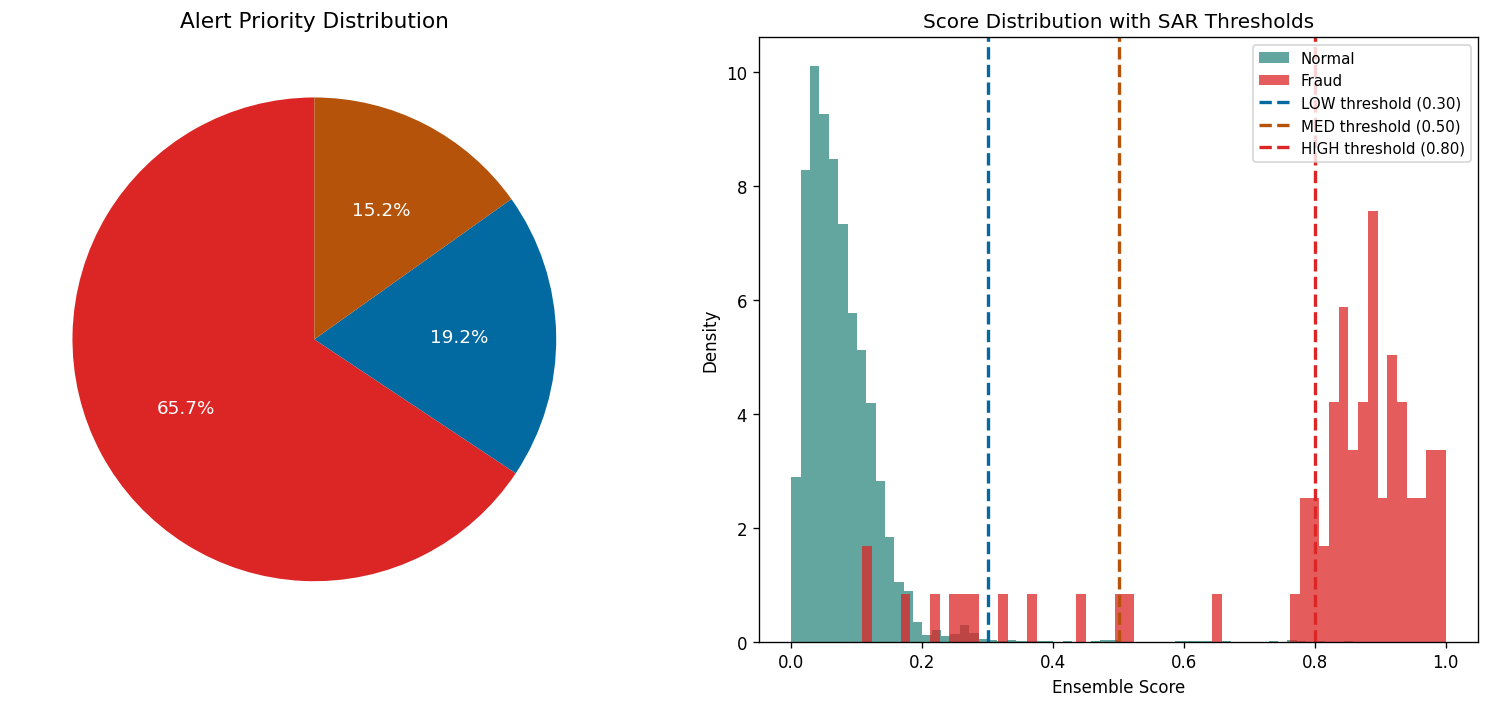

In [5]:
# Alert priority distribution pie chart
from collections import Counter
priority_counts = Counter(a.priority.value for a in alerts)
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

colours_pie = {'HIGH': '#dc2626', 'MEDIUM': '#b45309', 'LOW': '#0369a1'}
labels = list(priority_counts.keys())
values = list(priority_counts.values())
pie_colours = [colours_pie.get(l, '#475569') for l in labels]
axes[0].pie(values, labels=[f"{l}\n({v})" for l, v in zip(labels, values)],
            colors=pie_colours, autopct='%1.1f%%', startangle=90,
            textprops={'color': 'white', 'fontsize': 11})
axes[0].set_title('Alert Priority Distribution', fontsize=13)

# Score distribution with thresholds
axes[1].hist(ens_scores[y_true==0], bins=60, alpha=0.65, color='#0f766e', label='Normal', density=True)
axes[1].hist(ens_scores[y_true==1], bins=60, alpha=0.75, color='#dc2626', label='Fraud', density=True)
axes[1].axvline(0.30, color='#0369a1', ls='--', lw=2, label='LOW threshold (0.30)')
axes[1].axvline(0.50, color='#b45309', ls='--', lw=2, label='MED threshold (0.50)')
axes[1].axvline(0.80, color='#dc2626', ls='--', lw=2, label='HIGH threshold (0.80)')
axes[1].set_xlabel('Ensemble Score'); axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution with SAR Thresholds')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/04_sar_triage.png', dpi=150, bbox_inches='tight')
plt.show()

## Business Impact Summary

In [6]:
total_test = len(y_true)
total_fraud = int(y_true.sum())
m = evaluate(y_true, ens_scores, threshold=best_thresh)

# Assume average fraud transaction value £8,500
avg_fraud_value = 8_500

caught = m['tp']
missed = m['fn']
false_alarms = m['fp']

print("=" * 60)
print("  BUSINESS IMPACT — ENSEMBLE MODEL")
print("=" * 60)
print(f"  Transactions screened  : {total_test:,}")
print(f"  True fraud cases       : {total_fraud:,}")
print(f"  Fraud detected (TP)    : {caught:,}  ({caught/total_fraud:.1%} recall)")
print(f"  Fraud missed (FN)      : {missed:,}")
print(f"  False alerts (FP)      : {false_alarms:,}  ({m['fpr']:.1%} FPR)")
print(f"  Alert precision        : {m['precision']:.1%}  (of alerts, this % are real fraud)")
print()
print(f"  Estimated fraud value caught : £{caught * avg_fraud_value:,.0f}")
print(f"  Estimated fraud value missed : £{missed * avg_fraud_value:,.0f}")
print(f"  AUC-PR (primary metric)      : {average_precision_score(y_true, ens_scores):.3f}")
print("=" * 60)

  BUSINESS IMPACT — ENSEMBLE MODEL
  Transactions screened  : 4,000
  True fraud cases       : 80
  Fraud detected (TP)    : 67  (83.8% recall)
  Fraud missed (FN)      : 13
  False alerts (FP)      : 4  (0.1% FPR)
  Alert precision        : 94.4%  (of alerts, this % are real fraud)

  Estimated fraud value caught : £569,500
  Estimated fraud value missed : £110,500
  AUC-PR (primary metric)      : 0.930
